### Task-1-------finished by Maosheng Li
The goal of Task 1 was to implement the Canny edge detection algorithm from scratch, without using cv2.Canny, and then apply it to estimate the number of fence posts in an image.
The implementation followed the original five-stage pipeline of the Canny detector, followed by a heuristic post-counting method based on the vertical projection of edges.
#### Canny Edge Detection
 - Noise Reduction
 - Gradient Computation
 - Non-Maximum Suppression (NMS)
 - Double Thresholding
 - Edge Tracking by Hysteresis
#### Fence Post Counting
After obtaining the binary edge map:
Compute a column-wise sum (vertical projection).
Apply a moving average to smooth the signal.
Detect peaks in the 1-D profile using minimum distance and prominence criteria.
Each detected peak corresponds approximately to one fence post.

In [1]:
from dataclasses import dataclass
from typing import Tuple, List
import numpy as np

# ------------------------------
# Utility functions
# ------------------------------

def to_grayscale(img: np.ndarray) -> np.ndarray:
    if img.ndim == 2:
        return img.astype(np.float32)
    # Convert RGB/RGBA to grayscale using BT.601 luma
    return (0.299*img[...,0] + 0.587*img[...,1] + 0.114*img[...,2]).astype(np.float32)


def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Create a 2D Gaussian kernel normalized to sum 1."""
    assert size % 2 == 1, "Kernel size must be odd."
    ax = np.arange(-(size//2), size//2 + 1, dtype=np.float32)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2*sigma*sigma))
    kernel /= kernel.sum()
    return kernel


def convolve2d(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Simple 2D convolution with zero padding (same output size)."""
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    out = np.zeros_like(img, dtype=np.float32)
    # Flip kernel for convolution
    k = np.flipud(np.fliplr(kernel)).astype(np.float32)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * k)
    return out


def sobel_gradients(img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Compute image gradients using Sobel kernels."""
    Kx = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=np.float32)
    Ky = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=np.float32)
    gx = convolve2d(img, Kx)
    gy = convolve2d(img, Ky)
    return gx, gy


def non_maximum_suppression(mag: np.ndarray, ang: np.ndarray) -> np.ndarray:
    """Thin edges by keeping local maxima along gradient direction."""
    H, W = mag.shape
    Z = np.zeros((H, W), dtype=np.float32)
    # Map angles to 0,45,90,135 deg sectors
    angle = np.rad2deg(ang) % 180

    for i in range(1, H-1):
        for j in range(1, W-1):
            q = 0.0
            r = 0.0

            # 0 degrees
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = mag[i, j+1]
                r = mag[i, j-1]
            # 45 degrees
            elif (22.5 <= angle[i, j] < 67.5):
                q = mag[i+1, j-1]
                r = mag[i-1, j+1]
            # 90 degrees
            elif (67.5 <= angle[i, j] < 112.5):
                q = mag[i+1, j]
                r = mag[i-1, j]
            # 135 degrees
            elif (112.5 <= angle[i, j] < 157.5):
                q = mag[i-1, j-1]
                r = mag[i+1, j+1]

            if mag[i, j] >= q and mag[i, j] >= r:
                Z[i, j] = mag[i, j]
            else:
                Z[i, j] = 0.0
    return Z


def double_threshold(img: np.ndarray, low: float, high: float) -> np.ndarray:
    """Apply double thresholding; output labels: 0=non-edge, 1=weak, 2=strong."""
    strong = (img >= high).astype(np.uint8) * 2
    weak = ((img >= low) & (img < high)).astype(np.uint8)
    return strong + weak


def hysteresis(thresh_img: np.ndarray) -> np.ndarray:
    """Track edges by hysteresis: promote weak pixels connected to strong ones."""
    H, W = thresh_img.shape
    strong_val = 2
    weak_val = 1

    out = np.zeros_like(thresh_img, dtype=np.uint8)
    # Any weak connected (8-neigh) to strong becomes edge=1
    for i in range(1, H-1):
        for j in range(1, W-1):
            if thresh_img[i, j] == strong_val:
                out[i, j] = 1
            elif thresh_img[i, j] == weak_val:
                window = thresh_img[i-1:i+2, j-1:j+2]
                if np.any(window == strong_val):
                    out[i, j] = 1
                else:
                    out[i, j] = 0
    return out


@dataclass
class CannyParams:
    low: float = 30.0
    high: float = 90.0
    sigma: float = 1.4
    gaussian_size: int = 5

def canny(img: np.ndarray, params: CannyParams) -> Tuple[np.ndarray, dict]:
    """Full Canny pipeline; returns binary edges and intermediates."""
    gray = to_grayscale(img)

    # 1) Gaussian blur
    gk = gaussian_kernel(params.gaussian_size, params.sigma)
    smooth = convolve2d(gray, gk)

    # 2) Gradients
    gx, gy = sobel_gradients(smooth)
    mag = np.hypot(gx, gy)
    # Normalize magnitude to [0,255] for thresholding convenience
    mag = mag / (mag.max() + 1e-8) * 255.0
    ang = np.arctan2(gy, gx)

    # 3) Non-maximum suppression
    nms = non_maximum_suppression(mag, ang)

    # 4) Double threshold + hysteresis
    timg = double_threshold(nms, params.low, params.high)
    edges = hysteresis(timg)

    intermediates = {
        "gray": gray,
        "smooth": smooth,
        "grad_x": gx,
        "grad_y": gy,
        "mag": mag,
        "nms": nms,
        "timg": timg
    }
    return edges, intermediates


# ------------------------------
# Post counting (simple heuristic)
# ------------------------------

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    k = max(1, int(k))
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    c = np.convolve(xp, np.ones(k, dtype=np.float32)/k, mode="valid")
    return c


def find_peaks(signal: np.ndarray, min_distance: int = 10, prominence: float = 0.1) -> List[int]:
    """Very small peak detector; returns indices of peaks.
    - min_distance: minimum required separation between peaks (pixels)
    - prominence: fraction of (max - min) used as minimal peak height difference
    """
    smin, smax = float(signal.min()), float(signal.max())
    prom = prominence * (smax - smin)
    thresh = smin + prom

    peaks = []
    last_idx = -min_distance
    for i in range(1, len(signal)-1):
        if i - last_idx < min_distance:
            continue
        if signal[i] > signal[i-1] and signal[i] >= signal[i+1] and signal[i] >= thresh:
            peaks.append(i)
            last_idx = i
    return peaks


def count_posts(edge_map: np.ndarray,
                smooth_win: int = 15,
                min_distance: int = 25,
                prominence: float = 0.15) -> Tuple[int, List[int]]:
    """Estimate number of vertical posts in a fence from an edge map.
    Returns the count and the x-indexes of detected posts.
    """
    # Column-wise sum (vertical projection)
    col_strength = edge_map.sum(axis=0).astype(np.float32)
    col_strength_s = moving_average(col_strength, smooth_win)
    peaks = find_peaks(col_strength_s, min_distance=min_distance, prominence=prominence)
    return len(peaks), peaks

Estimated number of posts: 20
x-indexes of detected posts: [9, 43, 107, 143, 207, 243, 307, 344, 408, 443, 509, 546, 611, 647, 712, 748, 814, 848, 915, 950]


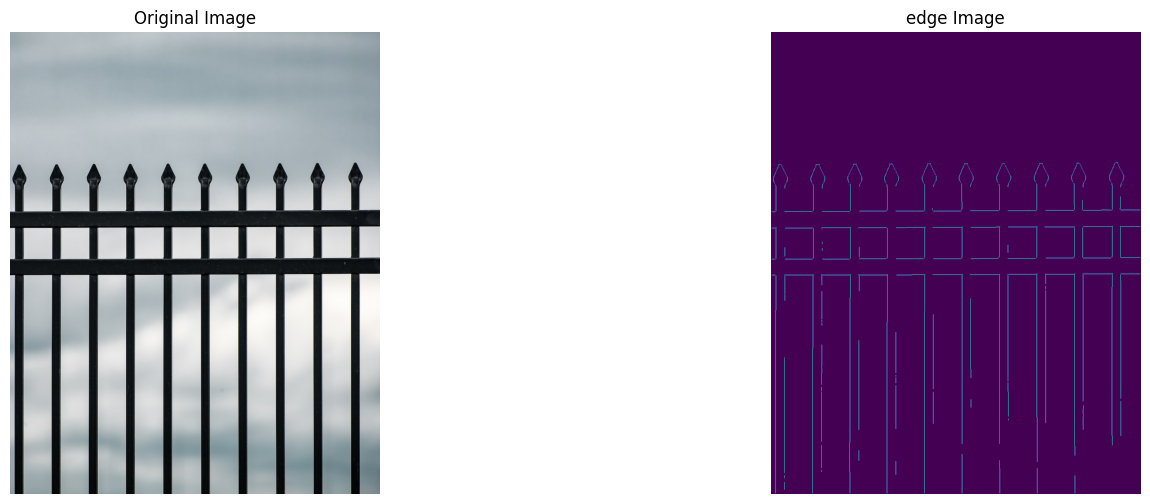

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../src/data/fence.jpg"
params = CannyParams(low=30, high=90, sigma=1.4, gaussian_size=5)

# === read img ===
img = np.array(Image.open(image_path).convert("RGB"))

# === Canny test ===
edges, inter = canny(img, params)

# === draw ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(edges*255)
axes[1].set_title("edge Image")
axes[1].axis("off")

# === count ===
n_posts, locations = count_posts(edges)
print(f"Estimated number of posts: {n_posts}")
print(f"x-indexes of detected posts: {locations}")


### Task-2--------finished by Xingyu Li
This task focuses on detecting blob-like structures (e.g., flower centers) using the Laplacian of Gaussian (LoG) method across multiple scales.
#### Laplacian of Gaussian
$$
\text{LoG}(x,y;\sigma)= \sigma^{2}\nabla^{2}\!\big(G(x,y;\sigma)*I(x,y)\big)
$$
  - where $ (G(x,y;\sigma)) $ is the Gaussian kernel and $ (I(x,y)) $ the input image.  
  - The factor $ (\sigma^{2}) $ provides scale normalization.
#### Blob Radius
 - The detected blob radius relates to the scale parameter as $r\approx\sqrt{2}\,\sigma$

In [3]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
from PIL import Image, ImageDraw

try:
    import cv2  # for optional comparison only
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False


# ------------------------------
# Basic image utilities
# ------------------------------

def load_gray(path: str) -> np.ndarray:
    img = Image.open(path).convert("L")
    return np.asarray(img, dtype=np.float32) / 255.0


def to_uint8(imgf: np.ndarray) -> np.ndarray:
    arr = imgf.astype(np.float32)
    arr = np.clip(arr, 0.0, 1.0)
    return (arr * 255.0 + 0.5).astype(np.uint8)


# ------------------------------
# Convolution & kernels
# ------------------------------

def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    assert size % 2 == 1
    ax = np.arange(-(size//2), size//2 + 1, dtype=np.float32)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2)/(2*sigma*sigma))
    k /= k.sum()
    return k


def convolve2d(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    out = np.zeros_like(img, dtype=np.float32)
    k = np.flipud(np.fliplr(kernel)).astype(np.float32)
    H, W = img.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * k)
    return out


# 2D Laplacian operator (discrete). We'll optionally use LoG via (Laplacian of Gaussian):
LAPLACIAN_KERNEL = np.array([[0,  1, 0],
                             [1, -4, 1],
                             [0,  1, 0]], dtype=np.float32)


def laplacian(img: np.ndarray) -> np.ndarray:
    return convolve2d(img, LAPLACIAN_KERNEL)


# ------------------------------
# LoG Multi-scale detection
# ------------------------------

from dataclasses import dataclass

@dataclass
class Blob:
    y: int
    x: int
    sigma: float
    response: float

    @property
    def radius(self) -> float:
        # For LoG, radius ~ sqrt(2) * sigma
        return float(np.sqrt(2.0) * self.sigma)


def log_response(img_gray: np.ndarray, sigma: float, normalize_scale: bool = True) -> np.ndarray:
    """Compute LoG response for one sigma:
        LoG ≈ Laplacian( GaussianBlur(img, sigma) )
    Optionally multiply by sigma^2 for scale normalization.
    """
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    g = gaussian_kernel(ksize, sigma)
    smoothed = convolve2d(img_gray, g)
    lap = laplacian(smoothed)
    if normalize_scale:
        lap = (sigma**2) * lap
    # Take absolute to detect bright/dark blobs; keep positive responses
    return np.abs(lap)


def nms_3d(scale_space: np.ndarray, sigmas: np.ndarray, threshold: float) -> list:
    """Non-maximum suppression in 3D (y, x, scale).
    threshold: relative to max of scale_space (0..1).
    """
    H, W, S = scale_space.shape
    M = scale_space.max()
    if M <= 1e-12:
        return []
    abs_thr = threshold * M

    blobs = []
    for s in range(1, S-1):
        # 3x3x3 neighborhood
        for i in range(1, H-1):
            for j in range(1, W-1):
                val = scale_space[i, j, s]
                if val < abs_thr:
                    continue
                patch = scale_space[i-1:i+2, j-1:j+2, s-1:s+2]
                if val >= np.max(patch):
                    blobs.append(Blob(y=i, x=j, sigma=float(sigmas[s]), response=float(val)))
    return blobs


def detect_blobs_log(
    image_path: str,
    sigmas: np.ndarray,
    threshold: float = 0.03,
    normalize_scale: bool = True
) -> list:
    """Run LoG blob detection over a set of sigmas.
    - threshold: relative to global max response in scale-space (0..1)
    - normalize_scale: True for sigma^2 * Laplacian (scale-invariant), False otherwise
    """
    img = load_gray(image_path)
    H, W = img.shape
    S = len(sigmas)

    # Build scale space (H, W, S)
    ss = np.zeros((H, W, S), dtype=np.float32)
    for k, sigma in enumerate(sigmas):
        ss[..., k] = log_response(img, float(sigma), normalize_scale=normalize_scale)

    blobs = nms_3d(ss, sigmas, threshold)
    return blobs


# ------------------------------
# Utilities: draw / sweep / compare
# ------------------------------

def draw_blobs(image_path: str, blobs: list, out_path: Optional[str] = None) -> Image.Image:
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    for b in blobs:
        r = b.radius
        x0, y0 = b.x - r, b.y - r
        x1, y1 = b.x + r, b.y + r
        draw.ellipse([x0, y0, x1, y1], outline=(255, 0, 0), width=2)
    if out_path is not None:
        img.save(out_path)
    return img


def sweep_thresholds(
    image_path: str,
    thresholds: list,
    sigmas: np.ndarray,
    normalize_scale: bool = True
) -> dict:
    """Run detections at multiple thresholds; return mapping threshold -> blobs."""
    results = {}
    for t in thresholds:
        blobs = detect_blobs_log(image_path, sigmas=sigmas, threshold=t, normalize_scale=normalize_scale)
        results[t] = blobs
    return results


def compare_with_opencv(image_path: str, out_path: Optional[str] = None):
    """Optional reference: use cv2.SimpleBlobDetector to detect blobs.
    This does NOT replace our LoG method; it's just for comparison.
    If OpenCV is not available, the function reports and returns None.
    """
    if not _HAS_CV2:
        print("OpenCV not installed; skipping comparison.")
        return None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Failed to read image via OpenCV.")
        return None

    params = cv2.SimpleBlobDetector_Params()
    params.filterByColor = False
    params.minThreshold = 10
    params.maxThreshold = 220
    params.thresholdStep = 10

    params.filterByArea = True
    params.minArea = 30
    params.maxArea = 5000

    params.filterByCircularity = False
    params.filterByConvexity = False
    params.filterByInertia = False

    detector = cv2.SimpleBlobDetector_create(params)
    keypoints = detector.detect(img)

    # Draw keypoints
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    vis = cv2.drawKeypoints(vis, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    if out_path is not None:
        cv2.imwrite(out_path, vis)

    # Return as a simple list of tuples for parity with Blob
    opencv_blobs = [(int(k.pt[0]), int(k.pt[1]), float(k.size/2.0)) for k in keypoints]
    return opencv_blobs

Normalized LoG: number of blobs = 1868
Non-normalized LoG: number of blobs = 0


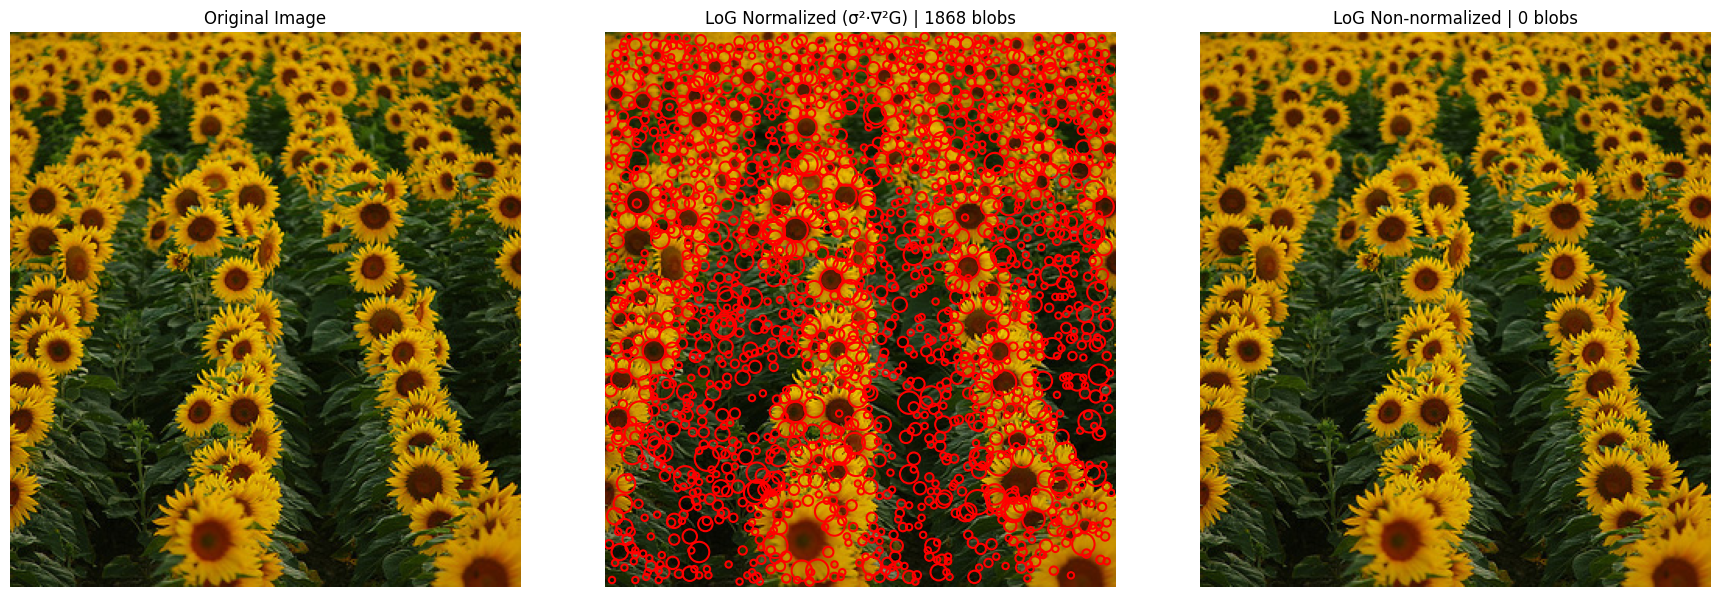

threshold=0.02 -> 1882 blobs
threshold=0.03 -> 1879 blobs
threshold=0.04 -> 1868 blobs
threshold=0.06 -> 1837 blobs
OpenCV detector: number of blobs = 249


In [4]:
img_path = "../src/data/flowers.png"
orig_color = np.array(Image.open(img_path).convert("RGB"))
orig_gray = np.array(Image.open(img_path).convert("L")) / 255.0
# === 1) （sigma^2 * Laplacian） ===
sigmas = np.linspace(1.0, 6.0, 12)
blobs_norm = detect_blobs_log(
    image_path=img_path,
    sigmas=sigmas,
    threshold=0.04,
    normalize_scale=True
)
print("Normalized LoG: number of blobs =", len(blobs_norm))
_ = draw_blobs(img_path, blobs_norm, out_path="flowers_log_norm.png")

# === 2) Non-normalized LoG ===
blobs_non = detect_blobs_log(
    image_path=img_path,
    sigmas=sigmas,
    threshold=0.04,
    normalize_scale=False
)
print("Non-normalized LoG: number of blobs =", len(blobs_non))
_ = draw_blobs(img_path, blobs_non, out_path="flowers_log_nonorm.png")

# === draw ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(orig_color)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(orig_color)
axes[1].set_title(f"LoG Normalized (σ²·∇²G) | {len(blobs_norm)} blobs")
axes[1].axis("off")
for b in blobs_norm:
    c = plt.Circle((b.x, b.y), b.radius, color='red', fill=False, linewidth=1.5)
    axes[1].add_patch(c)

axes[2].imshow(orig_color)
axes[2].set_title(f"LoG Non-normalized | {len(blobs_non)} blobs")
axes[2].axis("off")
for b in blobs_non:
    c = plt.Circle((b.x, b.y), b.radius, color='lime', fill=False, linewidth=1.5)
    axes[2].add_patch(c)

plt.tight_layout()
plt.show()

# === 3) comparison of different thresholds ===
thresholds = [0.02, 0.03, 0.04, 0.06]
sweep = sweep_thresholds(
    image_path=img_path,
    thresholds=thresholds,
    sigmas=sigmas,
    normalize_scale=True
)
for t, blobs in sweep.items():
    print(f"threshold={t:.2f} -> {len(blobs)} blobs")
    _ = draw_blobs(img_path, blobs, out_path=f"flowers_log_norm_t{str(t).replace('.','_')}.png")

# === 4) 与 OpenCV 的 SimpleBlobDetector 对比 ===
opencv_blobs = compare_with_opencv(img_path, out_path="flowers_opencv_blobs.png")
if opencv_blobs is not None:
    print("OpenCV detector: number of blobs =", len(opencv_blobs))
